In [66]:
# ============================================
# FICHIER 2 : MODÉLISATION ML
# ============================================

print("="*60)
print("MODÉLISATION MACHINE LEARNING")
print("="*60)

# Import des librairies
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
from datetime import datetime

# Machine Learning
from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import xgboost as xgb

# Sauvegarde des modèles
import pickle

# Configuration
warnings.filterwarnings('ignore')
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")
pd.set_option('display.max_columns', None)



MODÉLISATION MACHINE LEARNING


In [67]:
# ============================================
# SECTION 2 : CHARGEMENT DES DONNÉES
# ============================================


# Chargement du dataset
data_path = 'Data/cleaned_data.csv'
df = pd.read_csv(data_path)

print(f"\n Dataset chargé : {data_path}")
print(f"Dimensions     : {df.shape[0]} lignes × {df.shape[1]} colonnes")
print(f"Taille mémoire : {df.memory_usage(deep=True).sum() / 1024**2:.2f} MB")



# Vérification
print("\n" + "="*60)
print("🔍 VÉRIFICATION DES DONNÉES")
print("="*60)
print(f"Valeurs manquantes : {df.isnull().sum().sum()}")
print(f"Valeurs dupliquées : {df.duplicated().sum()}")

# Séparation features / target
print("\n" + "="*60)
print("SÉPARATION FEATURES / TARGET")
print("="*60)

# Liste des colonnes
print("\nColonnes disponibles :")
for i, col in enumerate(df.columns, 1):
    print(f"{i:2d}. {col}")

# Séparation X et y
X = df.drop('generated_power_kw', axis=1)
y = df['generated_power_kw']




 Dataset chargé : Data/cleaned_data.csv
Dimensions     : 4213 lignes × 21 colonnes
Taille mémoire : 0.68 MB

🔍 VÉRIFICATION DES DONNÉES
Valeurs manquantes : 0
Valeurs dupliquées : 0

SÉPARATION FEATURES / TARGET

Colonnes disponibles :
 1. zenith
 2. angle_of_incidence
 3. shortwave_radiation_backwards_sfc
 4. low_zenith
 5. radiation_temp_interaction
 6. humidity_temp_ratio
 7. relative_humidity_2_m_above_gnd
 8. total_cloud_cover_sfc
 9. total_cloud_all_layers
10. low_cloud_cover_low_cld_lay
11. medium_cloud_cover_mid_cld_lay
12. temperature_2_m_above_gnd
13. wind_speed_80_m_above_gnd
14. mean_sea_level_pressure_MSL
15. high_cloud_cover_high_cld_lay
16. wind_gust_10_m_above_gnd
17. total_precip
18. avg_wind_speed
19. total_precipitation_sfc
20. wind_speed_900_mb
21. generated_power_kw


In [ ]:
print("\n" + "="*60)
print("DONNÉES SÉPARÉES")
print("="*60)
print(f"X (features) : {X.shape[0]} lignes × {X.shape[1]} colonnes")
print(f"y (target)   : {y.shape[0]} valeurs")



In [68]:
# ============================================
# SECTION 3 : TRAIN/TEST SPLIT & NORMALISATION
# ============================================

print("="*60)
print("SÉPARATION TRAIN/TEST")
print("="*60)

# Séparation train/test (80/20)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print(f"\nSplit effectué (80% train / 20% test)")
print(f"\nDimensions :")
print(f"   X_train : {X_train.shape[0]} lignes × {X_train.shape[1]} colonnes")
print(f"   X_test  : {X_test.shape[0]} lignes × {X_test.shape[1]} colonnes")
print(f"   y_train : {y_train.shape[0]} valeurs")
print(f"   y_test  : {y_test.shape[0]} valeurs")

# Normalisation des données
print("\n" + "="*60)
print(" NORMALISATION DES DONNÉES (StandardScaler)")
print("="*60)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)



SÉPARATION TRAIN/TEST

Split effectué (80% train / 20% test)

Dimensions :
   X_train : 3370 lignes × 20 colonnes
   X_test  : 843 lignes × 20 colonnes
   y_train : 3370 valeurs
   y_test  : 843 valeurs

 NORMALISATION DES DONNÉES (StandardScaler)


In [69]:
# Conversion en DataFrame pour faciliter l'utilisation
X_train_scaled = pd.DataFrame(X_train_scaled, columns=X_train.columns, index=X_train.index)
X_test_scaled = pd.DataFrame(X_test_scaled, columns=X_test.columns, index=X_test.index)

print("\n" + "="*60)
print("DONNÉES PRÊTES POUR LA MODÉLISATION")
print("="*60)
print("\n📋 Ensembles disponibles :")
print("   1. X_train, y_train (données originales)")
print("   2. X_train_scaled, y_train (données normalisées)")
print("   3. X_test, y_test (données originales)")
print("   4. X_test_scaled, y_test (données normalisées)")
print("   5. scaler (objet pour normaliser de nouvelles données)")
print("="*60)


DONNÉES PRÊTES POUR LA MODÉLISATION

📋 Ensembles disponibles :
   1. X_train, y_train (données originales)
   2. X_train_scaled, y_train (données normalisées)
   3. X_test, y_test (données originales)
   4. X_test_scaled, y_test (données normalisées)
   5. scaler (objet pour normaliser de nouvelles données)


In [70]:
# ============================================
# SECTION 4 : MODÈLE 1 - RÉGRESSION LINÉAIRE
# ============================================

print("="*60)
print("MODÈLE 1 : RÉGRESSION LINÉAIRE (BASELINE)")
print("="*60)

# Initialisation du modèle
lr_model = LinearRegression()

print("\n🔧 Entraînement du modèle...")
# Entraînement
lr_model.fit(X_train_scaled, y_train)

# Prédictions
y_train_pred_lr = lr_model.predict(X_train_scaled)
y_test_pred_lr = lr_model.predict(X_test_scaled)

print("Modèle entraîné !\n")

# Évaluation sur le TRAIN
print("="*60)
print("PERFORMANCES SUR LE TRAIN")
print("="*60)
mae_train_lr = mean_absolute_error(y_train, y_train_pred_lr)
rmse_train_lr = np.sqrt(mean_squared_error(y_train, y_train_pred_lr))
r2_train_lr = r2_score(y_train, y_train_pred_lr)

print(f"MAE  : {mae_train_lr:.2f} kW")
print(f"RMSE : {rmse_train_lr:.2f} kW")
print(f"R²   : {r2_train_lr:.4f}")

# Évaluation sur le TEST
print("\n" + "="*60)
print("PERFORMANCES SUR LE TEST")
print("="*60)
mae_test_lr = mean_absolute_error(y_test, y_test_pred_lr)
rmse_test_lr = np.sqrt(mean_squared_error(y_test, y_test_pred_lr))
r2_test_lr = r2_score(y_test, y_test_pred_lr)

print(f"MAE  : {mae_test_lr:.2f} kW")
print(f"RMSE : {rmse_test_lr:.2f} kW")
print(f"R²   : {r2_test_lr:.4f}")



MODÈLE 1 : RÉGRESSION LINÉAIRE (BASELINE)

🔧 Entraînement du modèle...
Modèle entraîné !

PERFORMANCES SUR LE TRAIN
MAE  : 450.69 kW
RMSE : 563.00 kW
R²   : 0.6361

PERFORMANCES SUR LE TEST
MAE  : 451.59 kW
RMSE : 564.50 kW
R²   : 0.6512



TOP 10 FEATURES LES PLUS IMPORTANTES (coefficients)
                        Feature  Coefficient
            humidity_temp_ratio -3146.541601
relative_humidity_2_m_above_gnd  3055.880455
                 avg_wind_speed  -611.061590
                         zenith  -496.940999
      wind_speed_80_m_above_gnd   491.937845
      temperature_2_m_above_gnd  -312.336807
             angle_of_incidence  -277.500609
        total_precipitation_sfc  -272.871203
                   total_precip   245.895091
    mean_sea_level_pressure_MSL   143.793353

Génération des graphiques


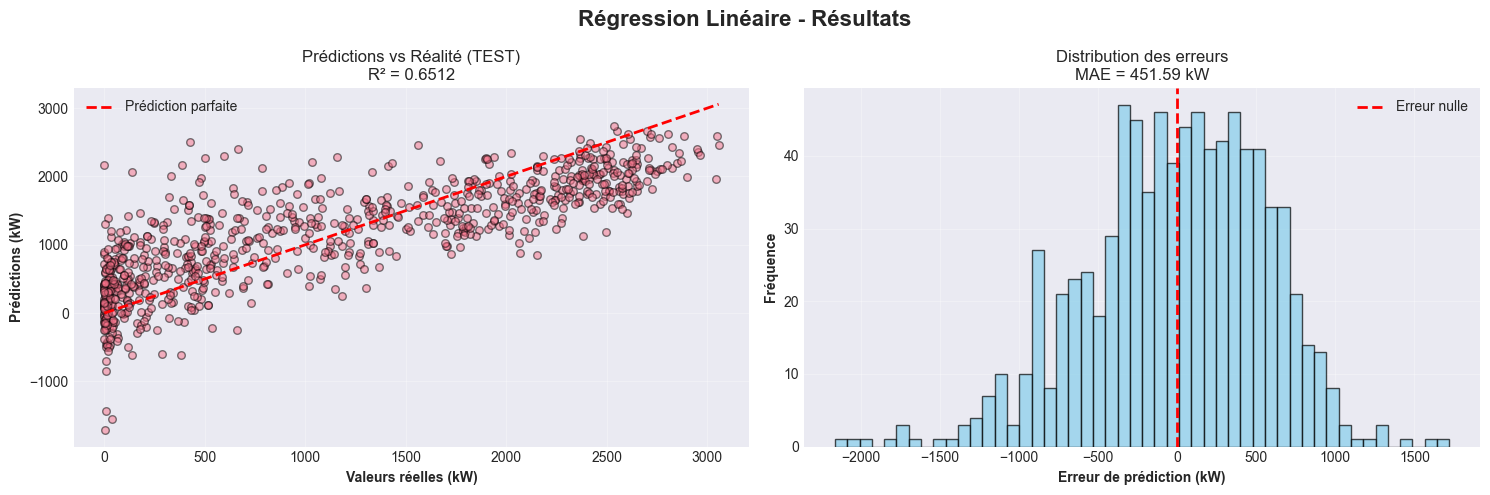

In [71]:
# Analyse des coefficients
print("\n" + "="*60)
print("TOP 10 FEATURES LES PLUS IMPORTANTES (coefficients)")
print("="*60)
coefficients = pd.DataFrame({
    'Feature': X_train.columns,
    'Coefficient': lr_model.coef_
})
coefficients['Abs_Coefficient'] = coefficients['Coefficient'].abs()
coefficients_sorted = coefficients.sort_values('Abs_Coefficient', ascending=False)

print(coefficients_sorted[['Feature', 'Coefficient']].head(10).to_string(index=False))

# Visualisation
print("\n" + "="*60)
print("Génération des graphiques")
print("="*60)

fig, axes = plt.subplots(1, 2, figsize=(15, 5))
fig.suptitle('Régression Linéaire - Résultats', fontsize=16, fontweight='bold')

# Graphique 1 : Prédictions vs Réalité (TEST)
axes[0].scatter(y_test, y_test_pred_lr, alpha=0.5, s=30, edgecolors='black')
axes[0].plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 
             'r--', lw=2, label='Prédiction parfaite')
axes[0].set_xlabel('Valeurs réelles (kW)', fontweight='bold')
axes[0].set_ylabel('Prédictions (kW)', fontweight='bold')
axes[0].set_title(f'Prédictions vs Réalité (TEST)\nR² = {r2_test_lr:.4f}')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Graphique 2 : Distribution des erreurs
residuals = y_test - y_test_pred_lr
axes[1].hist(residuals, bins=50, color='skyblue', edgecolor='black', alpha=0.7)
axes[1].axvline(x=0, color='red', linestyle='--', linewidth=2, label='Erreur nulle')
axes[1].set_xlabel('Erreur de prédiction (kW)', fontweight='bold')
axes[1].set_ylabel('Fréquence', fontweight='bold')
axes[1].set_title(f'Distribution des erreurs\nMAE = {mae_test_lr:.2f} kW')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('Outputs/05_linear_regression_results.png', dpi=300, bbox_inches='tight')
plt.show()



In [72]:
# ============================================
# SECTION 5 : MODÈLE 2 - RANDOM FOREST
# ============================================

print("="*60)
print("MODÈLE 2 : RANDOM FOREST REGRESSOR")
print("="*60)

# Initialisation du modèle
rf_model = RandomForestRegressor(
    n_estimators=100,
    max_depth=20,
    min_samples_split=5,
    min_samples_leaf=2,
    random_state=42,
    n_jobs=-1  # Utiliser tous les CPU
)

print("\nEntraînement du modèle Random Forest...")
print("   (cela peut prendre quelques secondes...)")

# Entraînement (on utilise les données NON normalisées pour RF)
rf_model.fit(X_train, y_train)

# Prédictions
y_train_pred_rf = rf_model.predict(X_train)
y_test_pred_rf = rf_model.predict(X_test)

print("Modèle entraîné !\n")

# Évaluation sur le TRAIN
print("="*60)
print("PERFORMANCES SUR LE TRAIN")
print("="*60)
mae_train_rf = mean_absolute_error(y_train, y_train_pred_rf)
rmse_train_rf = np.sqrt(mean_squared_error(y_train, y_train_pred_rf))
r2_train_rf = r2_score(y_train, y_train_pred_rf)

print(f"MAE  : {mae_train_rf:.2f} kW")
print(f"RMSE : {rmse_train_rf:.2f} kW")
print(f"R²   : {r2_train_rf:.4f}")

# Évaluation sur le TEST
print("\n" + "="*60)
print("PERFORMANCES SUR LE TEST")
print("="*60)
mae_test_rf = mean_absolute_error(y_test, y_test_pred_rf)
rmse_test_rf = np.sqrt(mean_squared_error(y_test, y_test_pred_rf))
r2_test_rf = r2_score(y_test, y_test_pred_rf)

print(f"MAE  : {mae_test_rf:.2f} kW")
print(f"RMSE : {rmse_test_rf:.2f} kW")
print(f"R²   : {r2_test_rf:.4f}")



MODÈLE 2 : RANDOM FOREST REGRESSOR

Entraînement du modèle Random Forest...
   (cela peut prendre quelques secondes...)
Modèle entraîné !

PERFORMANCES SUR LE TRAIN
MAE  : 133.29 kW
RMSE : 211.55 kW
R²   : 0.9486

PERFORMANCES SUR LE TEST
MAE  : 277.11 kW
RMSE : 425.72 kW
R²   : 0.8016



TOP 10 FEATURES LES PLUS IMPORTANTES (importance)
                          Feature  Importance
               angle_of_incidence    0.411097
                           zenith    0.184372
           total_cloud_all_layers    0.081101
            total_cloud_cover_sfc    0.075990
shortwave_radiation_backwards_sfc    0.062918
      mean_sea_level_pressure_MSL    0.036221
         wind_gust_10_m_above_gnd    0.024208
        temperature_2_m_above_gnd    0.022206
       radiation_temp_interaction    0.018206
              humidity_temp_ratio    0.015583

Génération des graphiques


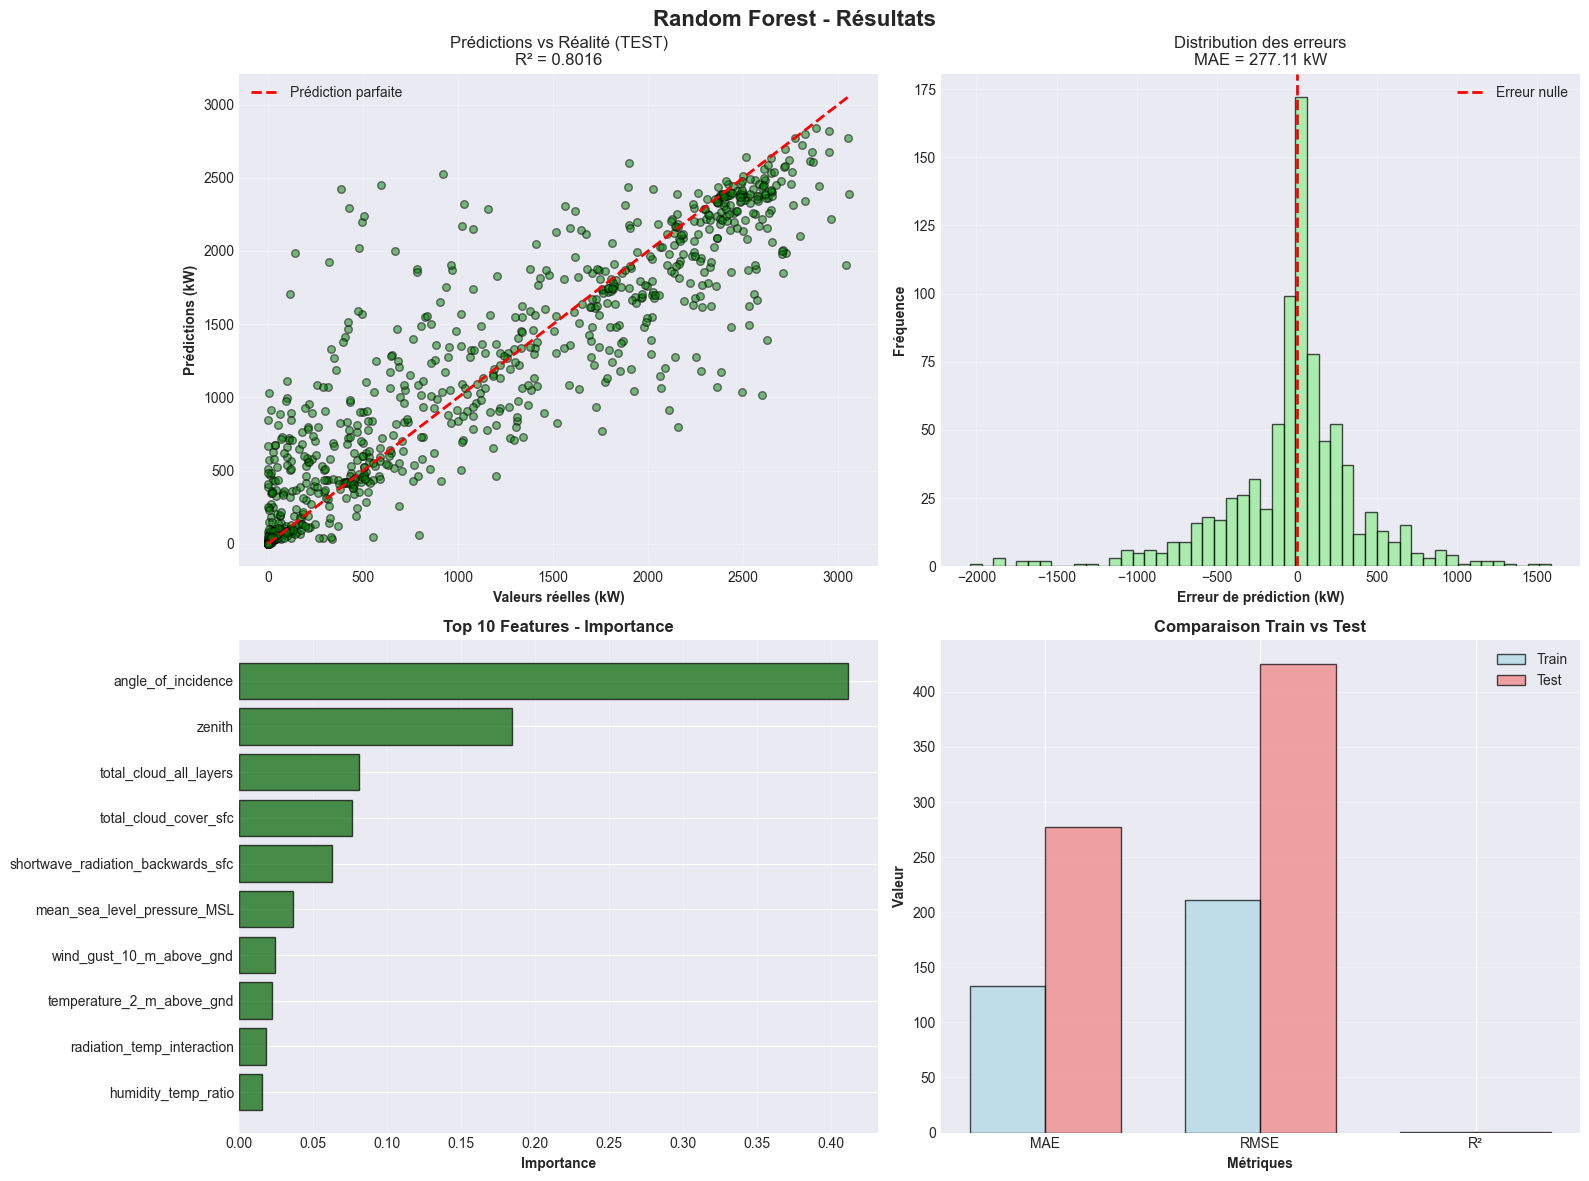

In [73]:
# Feature importance
print("\n" + "="*60)
print("TOP 10 FEATURES LES PLUS IMPORTANTES (importance)")
print("="*60)
feature_importance = pd.DataFrame({
    'Feature': X_train.columns,
    'Importance': rf_model.feature_importances_
})
feature_importance_sorted = feature_importance.sort_values('Importance', ascending=False)

print(feature_importance_sorted.head(10).to_string(index=False))

# Visualisation
print("\n" + "="*60)
print("Génération des graphiques")
print("="*60)

fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle('Random Forest - Résultats', fontsize=16, fontweight='bold')

# Graphique 1 : Prédictions vs Réalité (TEST)
axes[0, 0].scatter(y_test, y_test_pred_rf, alpha=0.5, s=30, edgecolors='black', color='green')
axes[0, 0].plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 
                'r--', lw=2, label='Prédiction parfaite')
axes[0, 0].set_xlabel('Valeurs réelles (kW)', fontweight='bold')
axes[0, 0].set_ylabel('Prédictions (kW)', fontweight='bold')
axes[0, 0].set_title(f'Prédictions vs Réalité (TEST)\nR² = {r2_test_rf:.4f}')
axes[0, 0].legend()
axes[0, 0].grid(True, alpha=0.3)

# Graphique 2 : Distribution des erreurs
residuals_rf = y_test - y_test_pred_rf
axes[0, 1].hist(residuals_rf, bins=50, color='lightgreen', edgecolor='black', alpha=0.7)
axes[0, 1].axvline(x=0, color='red', linestyle='--', linewidth=2, label='Erreur nulle')
axes[0, 1].set_xlabel('Erreur de prédiction (kW)', fontweight='bold')
axes[0, 1].set_ylabel('Fréquence', fontweight='bold')
axes[0, 1].set_title(f'Distribution des erreurs\nMAE = {mae_test_rf:.2f} kW')
axes[0, 1].legend()
axes[0, 1].grid(True, alpha=0.3)

# Graphique 3 : Feature Importance (Top 10)
top_10_features = feature_importance_sorted.head(10)
axes[1, 0].barh(top_10_features['Feature'], top_10_features['Importance'], 
                color='darkgreen', edgecolor='black', alpha=0.7)
axes[1, 0].set_xlabel('Importance', fontweight='bold')
axes[1, 0].set_title('Top 10 Features - Importance', fontweight='bold')
axes[1, 0].invert_yaxis()
axes[1, 0].grid(True, alpha=0.3, axis='x')

# Graphique 4 : Comparaison Train vs Test
metrics = ['MAE', 'RMSE', 'R²']
train_scores = [mae_train_rf, rmse_train_rf, r2_train_rf]
test_scores = [mae_test_rf, rmse_test_rf, r2_test_rf]

x = np.arange(len(metrics))
width = 0.35

axes[1, 1].bar(x - width/2, train_scores, width, label='Train', 
               color='lightblue', edgecolor='black', alpha=0.7)
axes[1, 1].bar(x + width/2, test_scores, width, label='Test', 
               color='lightcoral', edgecolor='black', alpha=0.7)
axes[1, 1].set_xlabel('Métriques', fontweight='bold')
axes[1, 1].set_ylabel('Valeur', fontweight='bold')
axes[1, 1].set_title('Comparaison Train vs Test', fontweight='bold')
axes[1, 1].set_xticks(x)
axes[1, 1].set_xticklabels(metrics)
axes[1, 1].legend()
axes[1, 1].grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.savefig('Outputs/06_random_forest_results.png', dpi=300, bbox_inches='tight')
plt.show()



In [74]:
# ============================================
# SECTION 6 : MODÈLE 3 - XGBOOST
# ============================================

print("="*60)
print("MODÈLE 3 : XGBOOST REGRESSOR")
print("="*60)

# Initialisation du modèle
xgb_model = xgb.XGBRegressor(
    n_estimators=100,
    max_depth=8,
    learning_rate=0.1,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    n_jobs=-1
)



# Entraînement
xgb_model.fit(X_train, y_train)

# Prédictions
y_train_pred_xgb = xgb_model.predict(X_train)
y_test_pred_xgb = xgb_model.predict(X_test)

print("Modèle entraîné !\n")

# Évaluation sur le TRAIN
print("="*60)
print("PERFORMANCES SUR LE TRAIN")
print("="*60)
mae_train_xgb = mean_absolute_error(y_train, y_train_pred_xgb)
rmse_train_xgb = np.sqrt(mean_squared_error(y_train, y_train_pred_xgb))
r2_train_xgb = r2_score(y_train, y_train_pred_xgb)

print(f"MAE  : {mae_train_xgb:.2f} kW")
print(f"RMSE : {rmse_train_xgb:.2f} kW")
print(f"R²   : {r2_train_xgb:.4f}")

# Évaluation sur le TEST
print("\n" + "="*60)
print("PERFORMANCES SUR LE TEST")
print("="*60)
mae_test_xgb = mean_absolute_error(y_test, y_test_pred_xgb)
rmse_test_xgb = np.sqrt(mean_squared_error(y_test, y_test_pred_xgb))
r2_test_xgb = r2_score(y_test, y_test_pred_xgb)

print(f"MAE  : {mae_test_xgb:.2f} kW")
print(f"RMSE : {rmse_test_xgb:.2f} kW")
print(f"R²   : {r2_test_xgb:.4f}")



MODÈLE 3 : XGBOOST REGRESSOR
Modèle entraîné !

PERFORMANCES SUR LE TRAIN
MAE  : 67.57 kW
RMSE : 99.08 kW
R²   : 0.9887

PERFORMANCES SUR LE TEST
MAE  : 268.12 kW
RMSE : 415.30 kW
R²   : 0.8112


In [75]:
# Feature importance
print("\n" + "="*60)
print("TOP 10 FEATURES LES PLUS IMPORTANTES (importance)")
print("="*60)
feature_importance_xgb = pd.DataFrame({
    'Feature': X_train.columns,
    'Importance': xgb_model.feature_importances_
})
feature_importance_xgb_sorted = feature_importance_xgb.sort_values('Importance', ascending=False)

print(feature_importance_xgb_sorted.head(10).to_string(index=False))




TOP 10 FEATURES LES PLUS IMPORTANTES (importance)
                          Feature  Importance
               angle_of_incidence    0.162031
           total_cloud_all_layers    0.161883
          total_precipitation_sfc    0.102835
            total_cloud_cover_sfc    0.079199
      low_cloud_cover_low_cld_lay    0.067629
                           zenith    0.059978
shortwave_radiation_backwards_sfc    0.038717
      mean_sea_level_pressure_MSL    0.037494
                       low_zenith    0.035679
                     total_precip    0.035070



Génération des graphiques


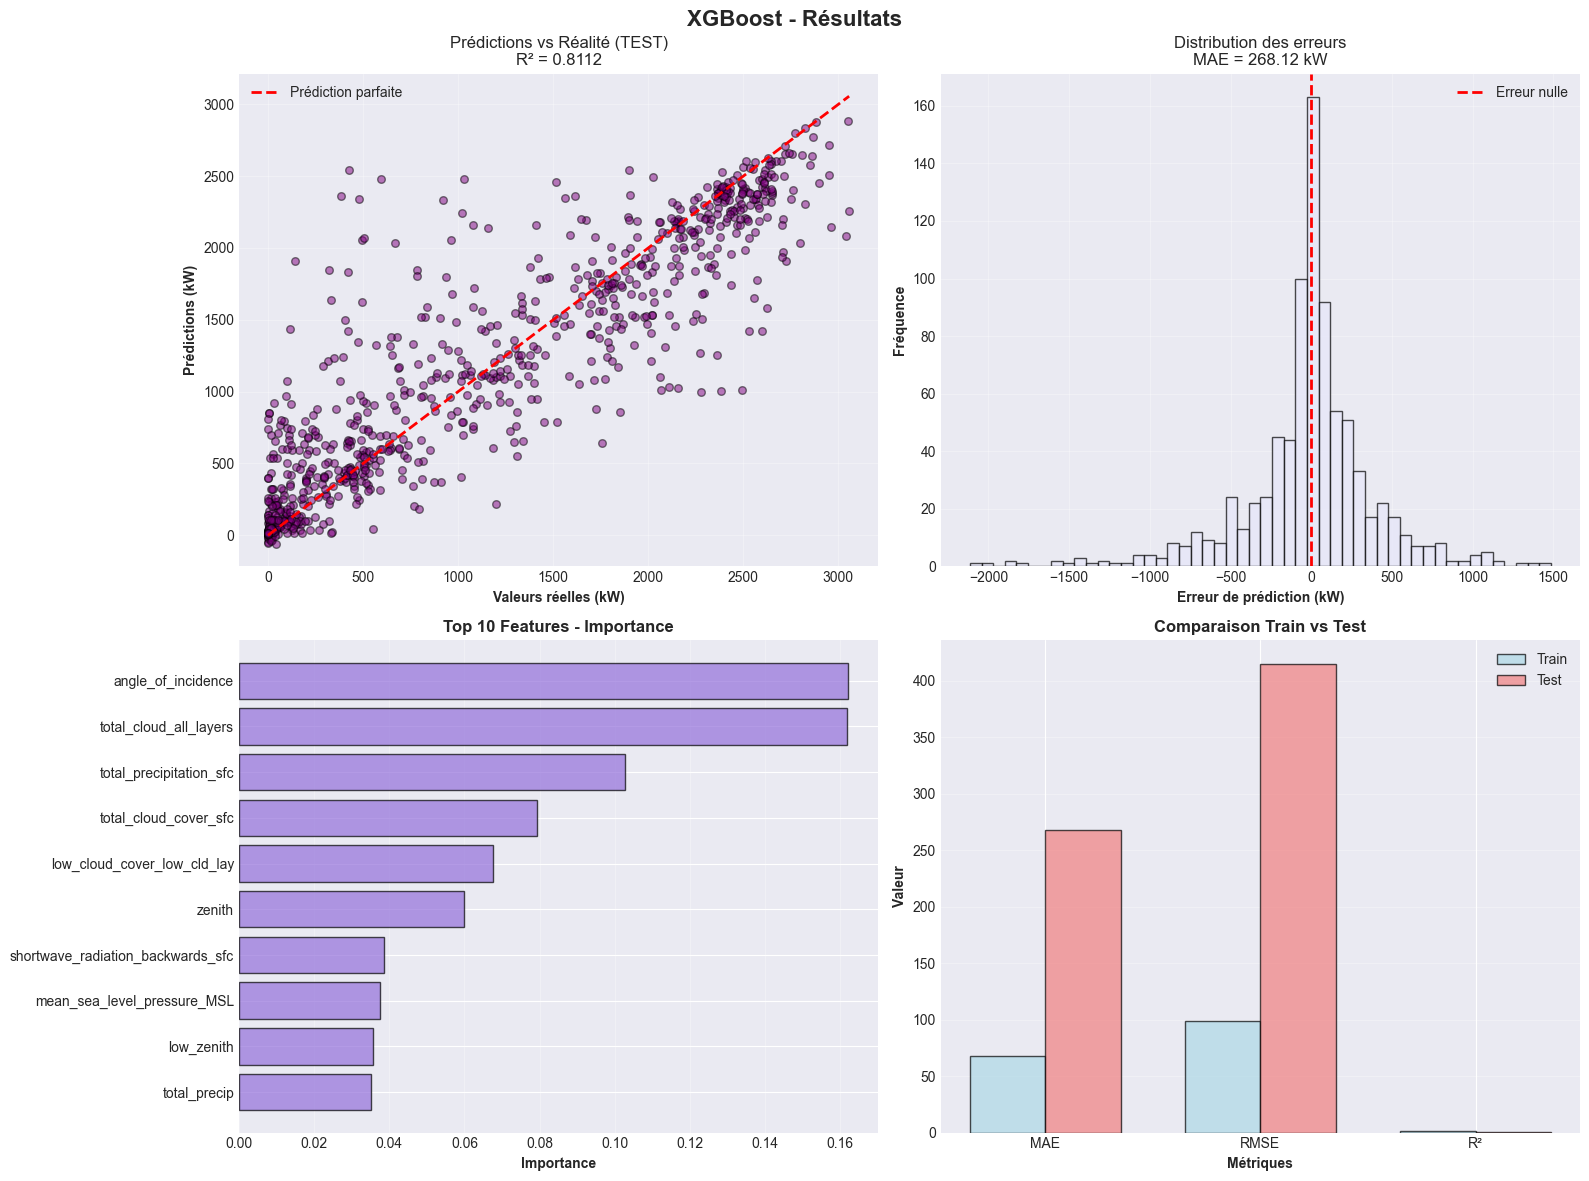

In [76]:
# Visualisation
print("\n" + "="*60)
print("Génération des graphiques")
print("="*60)

fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle('XGBoost - Résultats', fontsize=16, fontweight='bold')

# Graphique 1 : Prédictions vs Réalité (TEST)
axes[0, 0].scatter(y_test, y_test_pred_xgb, alpha=0.5, s=30, edgecolors='black', color='purple')
axes[0, 0].plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 
                'r--', lw=2, label='Prédiction parfaite')
axes[0, 0].set_xlabel('Valeurs réelles (kW)', fontweight='bold')
axes[0, 0].set_ylabel('Prédictions (kW)', fontweight='bold')
axes[0, 0].set_title(f'Prédictions vs Réalité (TEST)\nR² = {r2_test_xgb:.4f}')
axes[0, 0].legend()
axes[0, 0].grid(True, alpha=0.3)

# Graphique 2 : Distribution des erreurs
residuals_xgb = y_test - y_test_pred_xgb
axes[0, 1].hist(residuals_xgb, bins=50, color='lavender', edgecolor='black', alpha=0.7)
axes[0, 1].axvline(x=0, color='red', linestyle='--', linewidth=2, label='Erreur nulle')
axes[0, 1].set_xlabel('Erreur de prédiction (kW)', fontweight='bold')
axes[0, 1].set_ylabel('Fréquence', fontweight='bold')
axes[0, 1].set_title(f'Distribution des erreurs\nMAE = {mae_test_xgb:.2f} kW')
axes[0, 1].legend()
axes[0, 1].grid(True, alpha=0.3)

# Graphique 3 : Feature Importance (Top 10)
top_10_features_xgb = feature_importance_xgb_sorted.head(10)
axes[1, 0].barh(top_10_features_xgb['Feature'], top_10_features_xgb['Importance'], 
                color='mediumpurple', edgecolor='black', alpha=0.7)
axes[1, 0].set_xlabel('Importance', fontweight='bold')
axes[1, 0].set_title('Top 10 Features - Importance', fontweight='bold')
axes[1, 0].invert_yaxis()
axes[1, 0].grid(True, alpha=0.3, axis='x')

# Graphique 4 : Comparaison Train vs Test
metrics = ['MAE', 'RMSE', 'R²']
train_scores_xgb = [mae_train_xgb, rmse_train_xgb, r2_train_xgb]
test_scores_xgb = [mae_test_xgb, rmse_test_xgb, r2_test_xgb]

x = np.arange(len(metrics))
width = 0.35

axes[1, 1].bar(x - width/2, train_scores_xgb, width, label='Train', 
               color='lightblue', edgecolor='black', alpha=0.7)
axes[1, 1].bar(x + width/2, test_scores_xgb, width, label='Test', 
               color='lightcoral', edgecolor='black', alpha=0.7)
axes[1, 1].set_xlabel('Métriques', fontweight='bold')
axes[1, 1].set_ylabel('Valeur', fontweight='bold')
axes[1, 1].set_title('Comparaison Train vs Test', fontweight='bold')
axes[1, 1].set_xticks(x)
axes[1, 1].set_xticklabels(metrics)
axes[1, 1].legend()
axes[1, 1].grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.savefig('Outputs/07_xgboost_results.png', dpi=300, bbox_inches='tight')
plt.show()



In [77]:
# ============================================
# SECTION 7 : COMPARAISON DES 4 MODÈLES
# ============================================

print("="*60)
print("COMPARAISON DES 4 MODÈLES")
print("="*60)

# Création du tableau comparatif
comparison_df = pd.DataFrame({
    'Modèle': ['Régression Linéaire', 'Random Forest', 'XGBoost'],
    'MAE_Train': [mae_train_lr, mae_train_rf, mae_train_xgb],
    'RMSE_Train': [rmse_train_lr, rmse_train_rf, rmse_train_xgb],
    'R²_Train': [r2_train_lr, r2_train_rf, r2_train_xgb],
    'MAE_Test': [mae_test_lr, mae_test_rf, mae_test_xgb],
    'RMSE_Test': [rmse_test_lr, rmse_test_rf, rmse_test_xgb],
    'R²_Test': [r2_test_lr, r2_test_rf, r2_test_xgb]
})

print("\n RÉSULTATS SUR LE TRAIN :")
print("="*60)
print(comparison_df[['Modèle', 'MAE_Train', 'RMSE_Train', 'R²_Train']].to_string(index=False))

print("\nRÉSULTATS SUR LE TEST :")
print("="*60)
print(comparison_df[['Modèle', 'MAE_Test', 'RMSE_Test', 'R²_Test']].to_string(index=False))

# Identifier le meilleur modèle
best_model_idx = comparison_df['R²_Test'].idxmax()
best_model_name = comparison_df.loc[best_model_idx, 'Modèle']



COMPARAISON DES 4 MODÈLES

 RÉSULTATS SUR LE TRAIN :
             Modèle  MAE_Train  RMSE_Train  R²_Train
Régression Linéaire 450.689005  562.999551  0.636105
      Random Forest 133.288197  211.545412  0.948623
            XGBoost  67.573787   99.081365  0.988729

RÉSULTATS SUR LE TEST :
             Modèle   MAE_Test  RMSE_Test  R²_Test
Régression Linéaire 451.586075 564.497132 0.651155
      Random Forest 277.113225 425.721546 0.801592
            XGBoost 268.123774 415.300349 0.811186


In [78]:
print("\n" + "="*60)
print("MEILLEUR MODÈLE")
print("="*60)
print(f"Nom  : {best_model_name}")
print(f"MAE  : {comparison_df.loc[best_model_idx, 'MAE_Test']:.2f} kW")
print(f"RMSE : {comparison_df.loc[best_model_idx, 'RMSE_Test']:.2f} kW")
print(f"R²   : {comparison_df.loc[best_model_idx, 'R²_Test']:.4f}")

# Analyse de l'overfitting
print("\n" + "="*60)
print("ANALYSE DE L'OVERFITTING (R² Train - R² Test)")
print("="*60)
comparison_df['Overfitting'] = comparison_df['R²_Train'] - comparison_df['R²_Test']
print(comparison_df[['Modèle', 'R²_Train', 'R²_Test', 'Overfitting']].to_string(index=False))

print("\nInterprétation :")
print("   - Overfitting < 0.05  : Excellent (pas d'overfitting)")
print("   - Overfitting < 0.15  : Bon (overfitting léger)")
print("   - Overfitting > 0.15  : Attention (overfitting modéré à fort)")




MEILLEUR MODÈLE
Nom  : XGBoost
MAE  : 268.12 kW
RMSE : 415.30 kW
R²   : 0.8112

ANALYSE DE L'OVERFITTING (R² Train - R² Test)
             Modèle  R²_Train  R²_Test  Overfitting
Régression Linéaire  0.636105 0.651155    -0.015050
      Random Forest  0.948623 0.801592     0.147032
            XGBoost  0.988729 0.811186     0.177543

Interprétation :
   - Overfitting < 0.05  : Excellent (pas d'overfitting)
   - Overfitting < 0.15  : Bon (overfitting léger)
   - Overfitting > 0.15  : Attention (overfitting modéré à fort)



Génération du graphique comparatif...


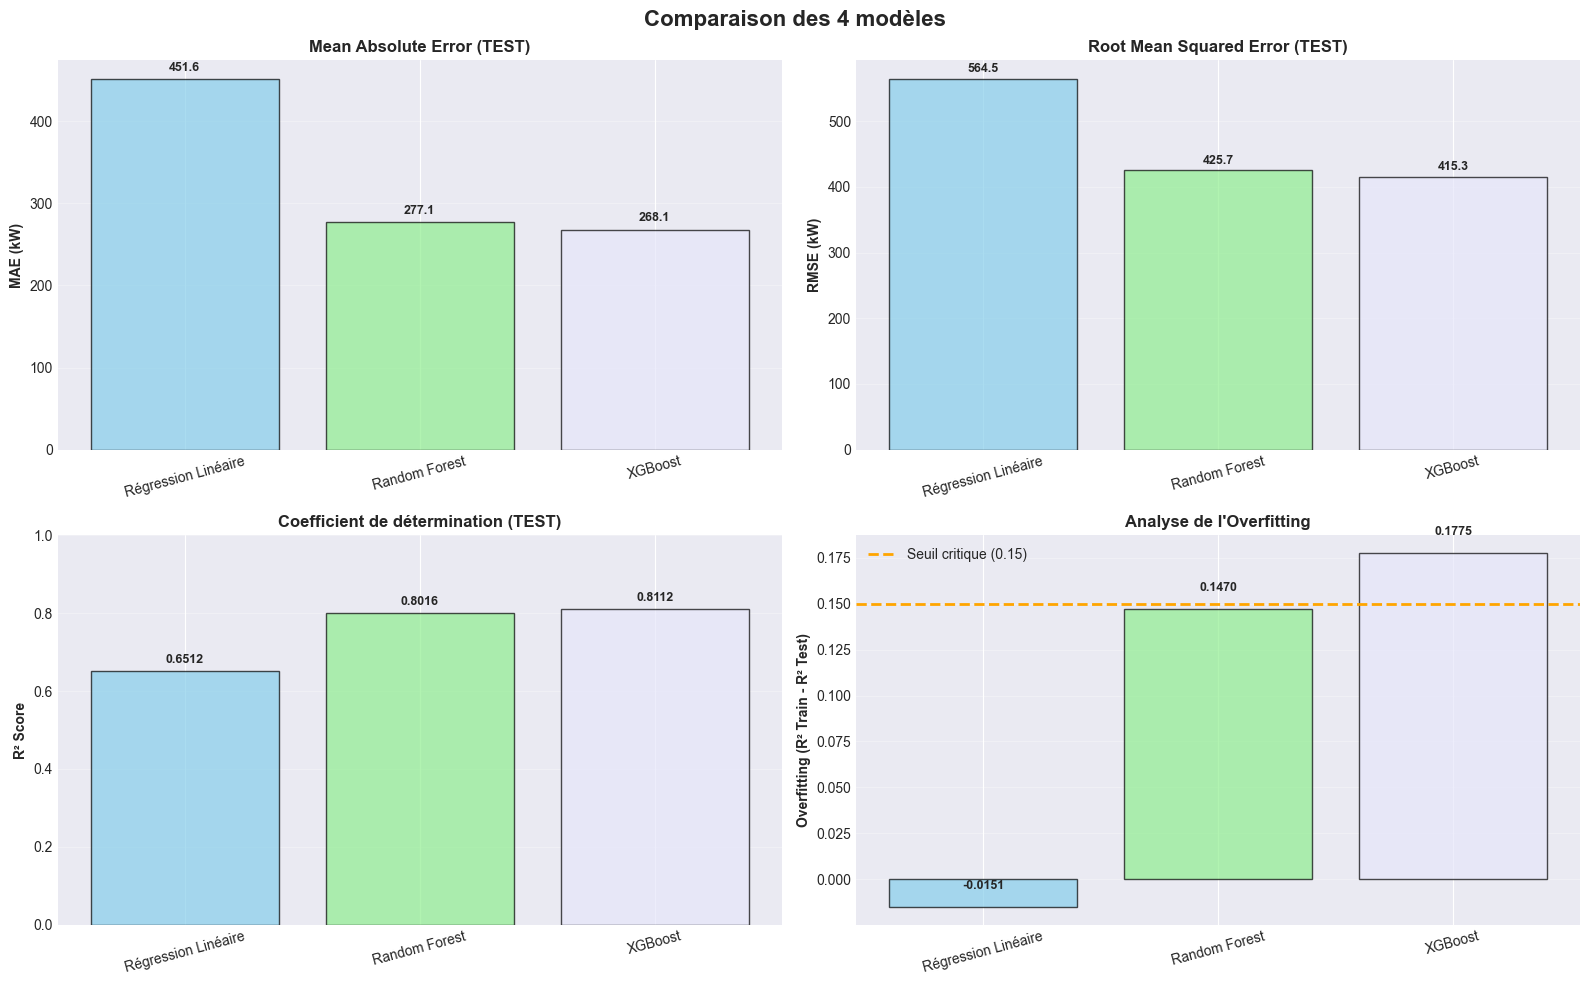

In [79]:
# Visualisation comparative
print("\n" + "="*60)
print("Génération du graphique comparatif...")
print("="*60)

fig, axes = plt.subplots(2, 2, figsize=(16, 10))
fig.suptitle('Comparaison des 4 modèles', fontsize=16, fontweight='bold')

models = comparison_df['Modèle'].tolist()
colors = ['skyblue', 'lightgreen', 'lavender', 'lightcoral']

# Graphique 1 : MAE (TEST)
axes[0, 0].bar(models, comparison_df['MAE_Test'], color=colors, edgecolor='black', alpha=0.7)
axes[0, 0].set_ylabel('MAE (kW)', fontweight='bold')
axes[0, 0].set_title('Mean Absolute Error (TEST)', fontweight='bold')
axes[0, 0].grid(True, alpha=0.3, axis='y')
axes[0, 0].tick_params(axis='x', rotation=15)
for i, v in enumerate(comparison_df['MAE_Test']):
    axes[0, 0].text(i, v + 10, f'{v:.1f}', ha='center', fontweight='bold', fontsize=9)

# Graphique 2 : RMSE (TEST)
axes[0, 1].bar(models, comparison_df['RMSE_Test'], color=colors, edgecolor='black', alpha=0.7)
axes[0, 1].set_ylabel('RMSE (kW)', fontweight='bold')
axes[0, 1].set_title('Root Mean Squared Error (TEST)', fontweight='bold')
axes[0, 1].grid(True, alpha=0.3, axis='y')
axes[0, 1].tick_params(axis='x', rotation=15)
for i, v in enumerate(comparison_df['RMSE_Test']):
    axes[0, 1].text(i, v + 10, f'{v:.1f}', ha='center', fontweight='bold', fontsize=9)

# Graphique 3 : R² (TEST)
axes[1, 0].bar(models, comparison_df['R²_Test'], color=colors, edgecolor='black', alpha=0.7)
axes[1, 0].set_ylabel('R² Score', fontweight='bold')
axes[1, 0].set_title('Coefficient de détermination (TEST)', fontweight='bold')
axes[1, 0].set_ylim([0, 1])
axes[1, 0].grid(True, alpha=0.3, axis='y')
axes[1, 0].tick_params(axis='x', rotation=15)
for i, v in enumerate(comparison_df['R²_Test']):
    axes[1, 0].text(i, v + 0.02, f'{v:.4f}', ha='center', fontweight='bold', fontsize=9)

# Graphique 4 : Overfitting
axes[1, 1].bar(models, comparison_df['Overfitting'], color=colors, edgecolor='black', alpha=0.7)
axes[1, 1].set_ylabel('Overfitting (R² Train - R² Test)', fontweight='bold')
axes[1, 1].set_title('Analyse de l\'Overfitting', fontweight='bold')
axes[1, 1].axhline(y=0.15, color='orange', linestyle='--', linewidth=2, label='Seuil critique (0.15)')
axes[1, 1].grid(True, alpha=0.3, axis='y')
axes[1, 1].tick_params(axis='x', rotation=15)
axes[1, 1].legend()
for i, v in enumerate(comparison_df['Overfitting']):
    axes[1, 1].text(i, v + 0.01, f'{v:.4f}', ha='center', fontweight='bold', fontsize=9)

plt.tight_layout()
plt.savefig('Outputs/08_models_comparison.png', dpi=300, bbox_inches='tight')
plt.show()



In [80]:
# ============================================
# SECTION 8 : OPTIMISATION DES 3 MODÈLES
# ============================================

print("="*60)
print("🔧 OPTIMISATION DES HYPERPARAMÈTRES - 3 MODÈLES")
print("="*60)
print("\n⏱️  ATTENTION : Cela peut prendre 10-20 minutes au total !")
print("="*60)

# Dictionnaire pour stocker les résultats
optimization_results = {}

# ============================================
# 1. RÉGRESSION LINÉAIRE (pas d'hyperparamètres majeurs à optimiser)
# ============================================
print("\n" + "="*60)
print("📈 1/3 : RÉGRESSION LINÉAIRE")
print("="*60)
print("ℹ️  Régression Linéaire n'a pas d'hyperparamètres à optimiser")
print("   (déjà optimal par défaut)")

optimization_results['Linear Regression'] = {
    'model': lr_model,
    'best_params': {},
    'mae_test': mae_test_lr,
    'rmse_test': rmse_test_lr,
    'r2_test': r2_test_lr,
    'mae_train': mae_train_lr,
    'r2_train': r2_train_lr
}

🔧 OPTIMISATION DES HYPERPARAMÈTRES - 3 MODÈLES

⏱️  ATTENTION : Cela peut prendre 10-20 minutes au total !

📈 1/3 : RÉGRESSION LINÉAIRE
ℹ️  Régression Linéaire n'a pas d'hyperparamètres à optimiser
   (déjà optimal par défaut)


In [81]:
# ============================================
# 2. RANDOM FOREST
# ============================================
print("\n" + "="*60)
print("🌲 2/3 : RANDOM FOREST - Optimisation en cours...")
print("="*60)

param_grid_rf = {
    'n_estimators': [100, 200, 300],
    'max_depth': [10, 20, 30, None],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'max_features': ['sqrt', 'log2']
}

print("📋 Paramètres à tester :")
for param, values in param_grid_rf.items():
    print(f"   {param:20s} : {values}")
print(f"\nCombinaisons : {np.prod([len(v) for v in param_grid_rf.values()])}")

grid_rf = GridSearchCV(
    estimator=RandomForestRegressor(random_state=42, n_jobs=-1),
    param_grid=param_grid_rf,
    cv=5,
    scoring='r2',
    n_jobs=-1,
    verbose=1
)

print("\nDémarrage...\n")
grid_rf.fit(X_train, y_train)

# Meilleur modèle
best_rf = grid_rf.best_estimator_
y_train_pred_rf_opt = best_rf.predict(X_train)
y_test_pred_rf_opt = best_rf.predict(X_test)

mae_test_rf_opt = mean_absolute_error(y_test, y_test_pred_rf_opt)
rmse_test_rf_opt = np.sqrt(mean_squared_error(y_test, y_test_pred_rf_opt))
r2_test_rf_opt = r2_score(y_test, y_test_pred_rf_opt)
mae_train_rf_opt = mean_absolute_error(y_train, y_train_pred_rf_opt)
r2_train_rf_opt = r2_score(y_train, y_train_pred_rf_opt)

print(f"\nTerminé !")
print(f"Meilleur score CV (R²) : {grid_rf.best_score_:.4f}")
print(f"Test R² : {r2_test_rf_opt:.4f}")

optimization_results['Random Forest'] = {
    'model': best_rf,
    'best_params': grid_rf.best_params_,
    'mae_test': mae_test_rf_opt,
    'rmse_test': rmse_test_rf_opt,
    'r2_test': r2_test_rf_opt,
    'mae_train': mae_train_rf_opt,
    'r2_train': r2_train_rf_opt
}



🌲 2/3 : RANDOM FOREST - Optimisation en cours...
📋 Paramètres à tester :
   n_estimators         : [100, 200, 300]
   max_depth            : [10, 20, 30, None]
   min_samples_split    : [2, 5, 10]
   min_samples_leaf     : [1, 2, 4]
   max_features         : ['sqrt', 'log2']

Combinaisons : 216

Démarrage...

Fitting 5 folds for each of 216 candidates, totalling 1080 fits

Terminé !
Meilleur score CV (R²) : 0.7711
Test R² : 0.8034


In [82]:
# ============================================
# 3. XGBOOST
# ============================================
print("\n" + "="*60)
print("3/3 : XGBOOST - Optimisation en cours...")
print("="*60)

param_grid_xgb = {
    'n_estimators': [100, 200, 300],
    'max_depth': [3, 5, 8, 10],
    'learning_rate': [0.01, 0.05, 0.1],
    'subsample': [0.7, 0.8, 0.9],
    'colsample_bytree': [0.7, 0.8, 0.9]
}

print("Paramètres à tester :")
for param, values in param_grid_xgb.items():
    print(f"   {param:20s} : {values}")
print(f"\n🔢 Combinaisons : {np.prod([len(v) for v in param_grid_xgb.values()])}")

grid_xgb = GridSearchCV(
    estimator=xgb.XGBRegressor(random_state=42, n_jobs=-1),
    param_grid=param_grid_xgb,
    cv=5,
    scoring='r2',
    n_jobs=-1,
    verbose=1
)

print("\nDémarrage...\n")
grid_xgb.fit(X_train, y_train)

# Meilleur modèle
best_xgb = grid_xgb.best_estimator_
y_train_pred_xgb_opt = best_xgb.predict(X_train)
y_test_pred_xgb_opt = best_xgb.predict(X_test)

mae_test_xgb_opt = mean_absolute_error(y_test, y_test_pred_xgb_opt)
rmse_test_xgb_opt = np.sqrt(mean_squared_error(y_test, y_test_pred_xgb_opt))
r2_test_xgb_opt = r2_score(y_test, y_test_pred_xgb_opt)
mae_train_xgb_opt = mean_absolute_error(y_train, y_train_pred_xgb_opt)
r2_train_xgb_opt = r2_score(y_train, y_train_pred_xgb_opt)

print(f"\n Terminé !")
print(f"Meilleur score CV (R²) : {grid_xgb.best_score_:.4f}")
print(f"Test R² : {r2_test_xgb_opt:.4f}")

optimization_results['XGBoost'] = {
    'model': best_xgb,
    'best_params': grid_xgb.best_params_,
    'mae_test': mae_test_xgb_opt,
    'rmse_test': rmse_test_xgb_opt,
    'r2_test': r2_test_xgb_opt,
    'mae_train': mae_train_xgb_opt,
    'r2_train': r2_train_xgb_opt
}


3/3 : XGBOOST - Optimisation en cours...
Paramètres à tester :
   n_estimators         : [100, 200, 300]
   max_depth            : [3, 5, 8, 10]
   learning_rate        : [0.01, 0.05, 0.1]
   subsample            : [0.7, 0.8, 0.9]
   colsample_bytree     : [0.7, 0.8, 0.9]

🔢 Combinaisons : 324

Démarrage...

Fitting 5 folds for each of 324 candidates, totalling 1620 fits

 Terminé !
Meilleur score CV (R²) : 0.7862
Test R² : 0.8172


In [90]:

# ============================================
# 1. MEILLEURS HYPERPARAMÈTRES
# ============================================
print("\n" + "="*60)
print("MEILLEURS HYPERPARAMÈTRES TROUVÉS")
print("="*60)

for model_name, results in optimization_results.items():
    print(f"\n🔹 {model_name.upper()}")
    if results['best_params']:
        for param, value in results['best_params'].items():
            print(f"   {param:20s} : {value}")
    else:
        print("   Pas d'hyperparamètres à optimiser")




MEILLEURS HYPERPARAMÈTRES TROUVÉS

🔹 LINEAR REGRESSION
   Pas d'hyperparamètres à optimiser

🔹 RANDOM FOREST
   max_depth            : 20
   max_features         : sqrt
   min_samples_leaf     : 1
   min_samples_split    : 2
   n_estimators         : 300

🔹 XGBOOST
   colsample_bytree     : 0.9
   learning_rate        : 0.05
   max_depth            : 8
   n_estimators         : 300
   subsample            : 0.7


In [91]:
# ============================================
# 2. COMPARAISON AVANT/APRÈS OPTIMISATION
# ============================================
print("\n" + "="*60)
print("COMPARAISON AVANT/APRÈS OPTIMISATION (TEST)")
print("="*60)

comparison_before_after = pd.DataFrame({
    'Modèle': ['Régression Linéaire', 'Random Forest', 'XGBoost'],
    'MAE_Avant': [mae_test_lr, mae_test_rf, mae_test_xgb],
    'MAE_Après': [mae_test_lr, mae_test_rf_opt, mae_test_xgb_opt],
    'RMSE_Avant': [rmse_test_lr, rmse_test_rf, rmse_test_xgb],
    'RMSE_Après': [rmse_test_lr, rmse_test_rf_opt, rmse_test_xgb_opt],
    'R²_Avant': [r2_test_lr, r2_test_rf, r2_test_xgb],
    'R²_Après': [r2_test_lr, r2_test_rf_opt, r2_test_xgb_opt]
})

# Calcul des améliorations
comparison_before_after['Amélioration_MAE_%'] = ((comparison_before_after['MAE_Avant'] - comparison_before_after['MAE_Après']) / comparison_before_after['MAE_Avant'] * 100).round(2)
comparison_before_after['Amélioration_R²_%'] = ((comparison_before_after['R²_Après'] - comparison_before_after['R²_Avant']) / comparison_before_after['R²_Avant'] * 100).round(2)

print("\n MAE (Mean Absolute Error) :")
print(comparison_before_after[['Modèle', 'MAE_Avant', 'MAE_Après', 'Amélioration_MAE_%']].to_string(index=False))

print("\nRMSE (Root Mean Squared Error) :")
print(comparison_before_after[['Modèle', 'RMSE_Avant', 'RMSE_Après']].to_string(index=False))

print("\nR² Score :")
print(comparison_before_after[['Modèle', 'R²_Avant', 'R²_Après', 'Amélioration_R²_%']].to_string(index=False))


COMPARAISON AVANT/APRÈS OPTIMISATION (TEST)

 MAE (Mean Absolute Error) :
             Modèle  MAE_Avant  MAE_Après  Amélioration_MAE_%
Régression Linéaire 451.586075 451.586075                0.00
      Random Forest 277.113225 296.176415               -6.88
            XGBoost 268.123774 263.739813                1.64

RMSE (Root Mean Squared Error) :
             Modèle  RMSE_Avant  RMSE_Après
Régression Linéaire  564.497132  564.497132
      Random Forest  425.721546  423.725082
            XGBoost  415.300349  408.655210

R² Score :
             Modèle  R²_Avant  R²_Après  Amélioration_R²_%
Régression Linéaire  0.651155  0.651155               0.00
      Random Forest  0.801592  0.803448               0.23
            XGBoost  0.811186  0.817180               0.74


In [92]:
# ============================================
# 3. CLASSEMENT FINAL
# ============================================
print("\n" + "="*60)
print("CLASSEMENT FINAL (MODÈLES OPTIMISÉS)")
print("="*60)

final_ranking = pd.DataFrame({
    'Modèle': ['Régression Linéaire', 'Random Forest', 'XGBoost'],
    'MAE_Test': [mae_test_lr, mae_test_rf_opt, mae_test_xgb_opt],
    'RMSE_Test': [rmse_test_lr, rmse_test_rf_opt, rmse_test_xgb_opt],
    'R²_Test': [r2_test_lr, r2_test_rf_opt, r2_test_xgb_opt],
    'Overfitting': [
        r2_train_lr - r2_test_lr,
        r2_train_rf_opt - r2_test_rf_opt,
        r2_train_xgb_opt - r2_test_xgb_opt,
        
    ]
})

final_ranking_sorted = final_ranking.sort_values('R²_Test', ascending=False).reset_index(drop=True)
final_ranking_sorted['Rang'] = final_ranking_sorted.index + 1

print("\n" + final_ranking_sorted[['Rang', 'Modèle', 'MAE_Test', 'RMSE_Test', 'R²_Test', 'Overfitting']].to_string(index=False))

# Identifier le meilleur modèle final
best_model_final = final_ranking_sorted.iloc[0]

print("\n" + "="*60)
print("CHAMPION FINAL")
print("="*60)
print(f"Modèle       : {best_model_final['Modèle']}")
print(f"MAE          : {best_model_final['MAE_Test']:.2f} kW")
print(f"RMSE         : {best_model_final['RMSE_Test']:.2f} kW")
print(f"R²           : {best_model_final['R²_Test']:.4f}")
print(f"Overfitting  : {best_model_final['Overfitting']:.4f}")




CLASSEMENT FINAL (MODÈLES OPTIMISÉS)

 Rang              Modèle   MAE_Test  RMSE_Test  R²_Test  Overfitting
    1             XGBoost 263.739813 408.655210 0.817180     0.178699
    2       Random Forest 296.176415 423.725082 0.803448     0.165148
    3 Régression Linéaire 451.586075 564.497132 0.651155    -0.015050

CHAMPION FINAL
Modèle       : XGBoost
MAE          : 263.74 kW
RMSE         : 408.66 kW
R²           : 0.8172
Overfitting  : 0.1787



Génération des graphiques comparatifs...


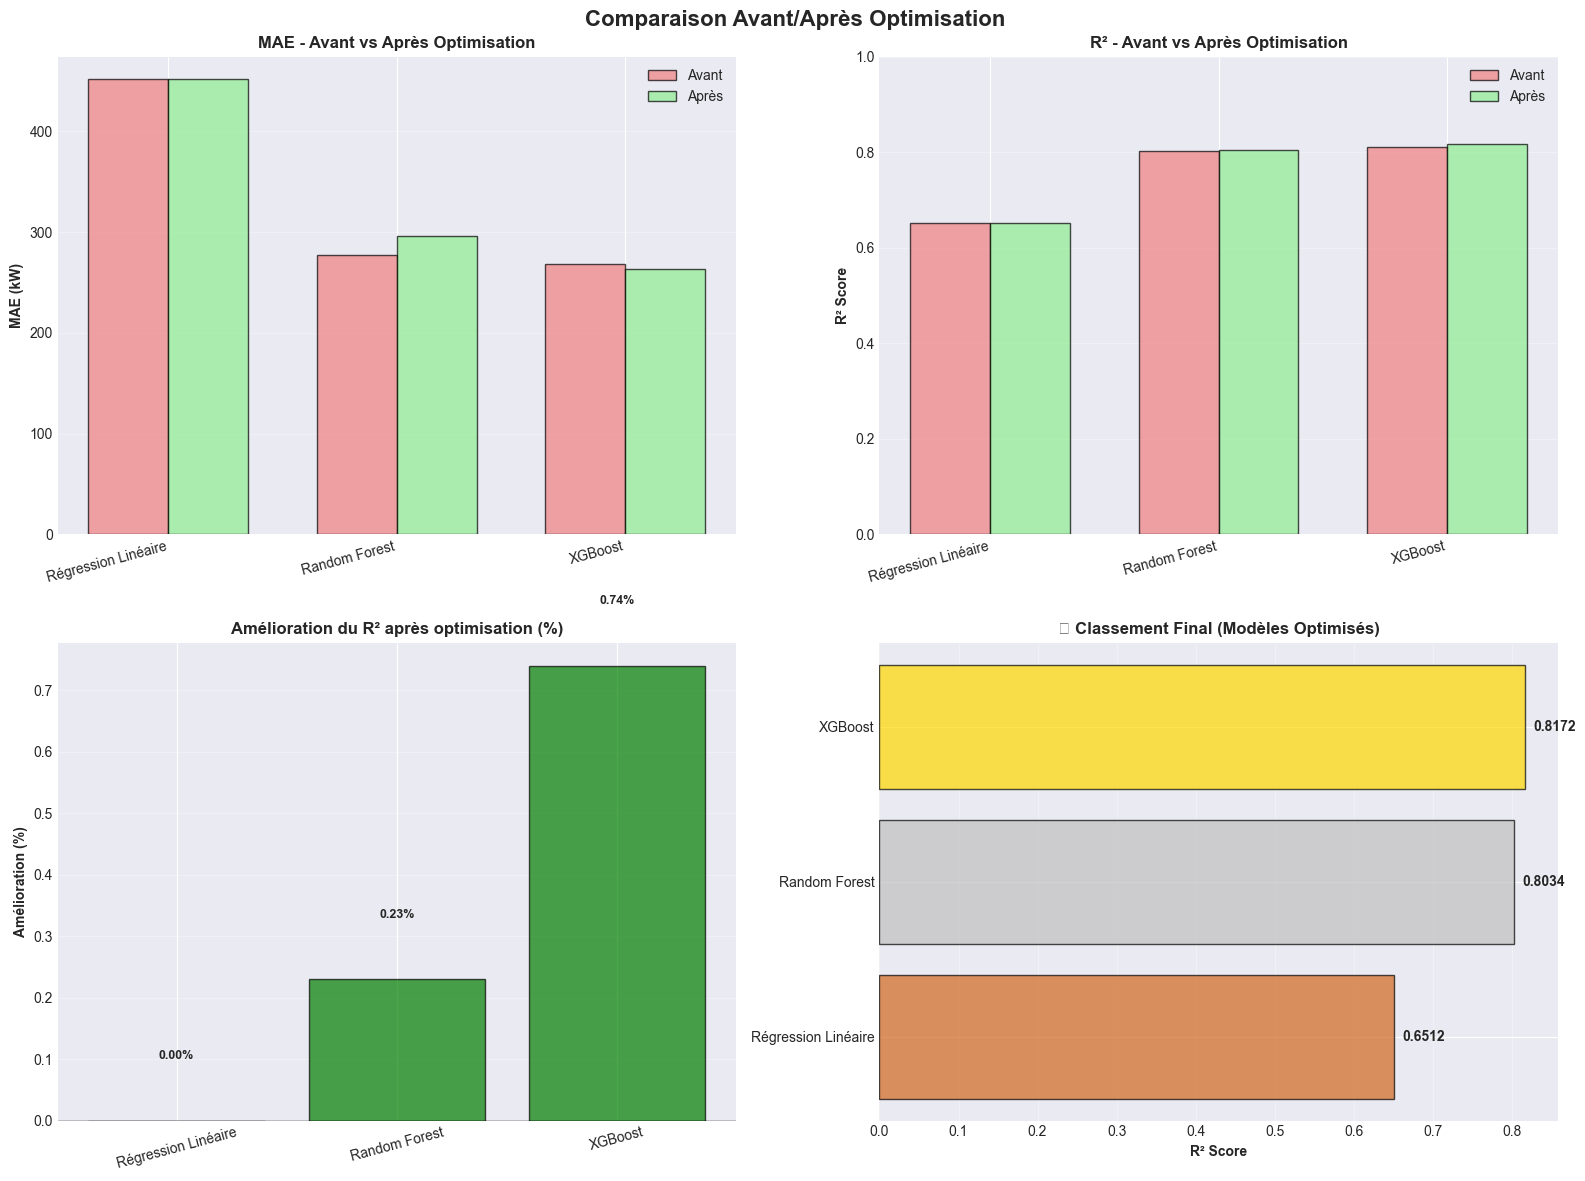

In [94]:
# ============================================
# 4. VISUALISATIONS
# ============================================
print("\n" + "="*60)
print("Génération des graphiques comparatifs...")
print("="*60)

fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle('Comparaison Avant/Après Optimisation', fontsize=16, fontweight='bold')

models = comparison_before_after['Modèle'].tolist()
x = np.arange(len(models))
width = 0.35

# Graphique 1 : MAE Avant/Après
axes[0, 0].bar(x - width/2, comparison_before_after['MAE_Avant'], width, 
               label='Avant', color='lightcoral', edgecolor='black', alpha=0.7)
axes[0, 0].bar(x + width/2, comparison_before_after['MAE_Après'], width, 
               label='Après', color='lightgreen', edgecolor='black', alpha=0.7)
axes[0, 0].set_ylabel('MAE (kW)', fontweight='bold')
axes[0, 0].set_title('MAE - Avant vs Après Optimisation', fontweight='bold')
axes[0, 0].set_xticks(x)
axes[0, 0].set_xticklabels(models, rotation=15, ha='right')
axes[0, 0].legend()
axes[0, 0].grid(True, alpha=0.3, axis='y')

# Graphique 2 : R² Avant/Après
axes[0, 1].bar(x - width/2, comparison_before_after['R²_Avant'], width, 
               label='Avant', color='lightcoral', edgecolor='black', alpha=0.7)
axes[0, 1].bar(x + width/2, comparison_before_after['R²_Après'], width, 
               label='Après', color='lightgreen', edgecolor='black', alpha=0.7)
axes[0, 1].set_ylabel('R² Score', fontweight='bold')
axes[0, 1].set_title('R² - Avant vs Après Optimisation', fontweight='bold')
axes[0, 1].set_xticks(x)
axes[0, 1].set_xticklabels(models, rotation=15, ha='right')
axes[0, 1].set_ylim([0, 1])
axes[0, 1].legend()
axes[0, 1].grid(True, alpha=0.3, axis='y')

# Graphique 3 : Amélioration en %
colors_improvement = ['gray' if x == 0 else 'green' if x > 0 else 'red' 
                      for x in comparison_before_after['Amélioration_R²_%']]
axes[1, 0].bar(models, comparison_before_after['Amélioration_R²_%'], 
               color=colors_improvement, edgecolor='black', alpha=0.7)
axes[1, 0].set_ylabel('Amélioration (%)', fontweight='bold')
axes[1, 0].set_title('Amélioration du R² après optimisation (%)', fontweight='bold')
axes[1, 0].axhline(y=0, color='black', linestyle='-', linewidth=1)
axes[1, 0].tick_params(axis='x', rotation=15)
axes[1, 0].grid(True, alpha=0.3, axis='y')
for i, v in enumerate(comparison_before_after['Amélioration_R²_%']):
    axes[1, 0].text(i, v + 0.1, f'{v:.2f}%', ha='center', fontweight='bold', fontsize=9)

# Graphique 4 : Classement final (R²)
colors_final = ['gold', 'silver', 'chocolate', 'lightgray']
axes[1, 1].barh(final_ranking_sorted['Modèle'], final_ranking_sorted['R²_Test'], 
                color=colors_final, edgecolor='black', alpha=0.7)
axes[1, 1].set_xlabel('R² Score', fontweight='bold')
axes[1, 1].set_title('🏆 Classement Final (Modèles Optimisés)', fontweight='bold')
axes[1, 1].invert_yaxis()
axes[1, 1].grid(True, alpha=0.3, axis='x')
for i, v in enumerate(final_ranking_sorted['R²_Test']):
    axes[1, 1].text(v + 0.01, i, f'{v:.4f}', va='center', fontweight='bold', fontsize=10)

plt.tight_layout()
plt.savefig('Outputs/09_optimization_comparison.png', dpi=300, bbox_inches='tight')
plt.show()



In [96]:
# ============================================
# SAUVEGARDE DU MODÈLE FINAL
# ============================================

print("="*60)
print(" SAUVEGARDE DU MODÈLE FINAL")
print("="*60)

# Récupération du meilleur modèle (XGBoost optimisé)
final_model = optimization_results['XGBoost']['model']
final_model_name = 'XGBoost Optimisé'

print(f"\nModèle sélectionné : {final_model_name}")
print(f"Performance (R² Test) : {r2_test_xgb_opt:.4f}")

# Sauvegarde du modèle avec pickle
model_path = 'Models/best_model_xgboost.pkl'
with open(model_path, 'wb') as f:
    pickle.dump(final_model, f)

print(f"\nModèle sauvegardé : {model_path}")

# Sauvegarde du scaler (important pour les prédictions futures)
scaler_path = 'Models/scaler.pkl'
with open(scaler_path, 'wb') as f:
    pickle.dump(scaler, f)

print(f"Scaler sauvegardé : {scaler_path}")


# Rechargement
with open(model_path, 'rb') as f:
    loaded_model = pickle.load(f)

with open(scaler_path, 'rb') as f:
    loaded_scaler = pickle.load(f)

# Test de prédiction
y_test_pred_loaded = loaded_model.predict(X_test)
r2_loaded = r2_score(y_test, y_test_pred_loaded)




 SAUVEGARDE DU MODÈLE FINAL

Modèle sélectionné : XGBoost Optimisé
Performance (R² Test) : 0.8172

Modèle sauvegardé : Models/best_model_xgboost.pkl
Scaler sauvegardé : Models/scaler.pkl


In [97]:
# Sauvegarde des métadonnées
print("\n" + "="*60)
print("SAUVEGARDE DES MÉTADONNÉES DU MODÈLE")
print("="*60)

metadata = {
    'model_name': final_model_name,
    'model_type': 'XGBoost Regressor',
    'features': list(X_train.columns),
    'n_features': len(X_train.columns),
    'target': 'generated_power_kw',
    'hyperparameters': optimization_results['XGBoost']['best_params'],
    'performance': {
        'mae_test': mae_test_xgb_opt,
        'rmse_test': rmse_test_xgb_opt,
        'r2_test': r2_test_xgb_opt,
        'mae_train': mae_train_xgb_opt,
        'r2_train': r2_train_xgb_opt,
        'overfitting': r2_train_xgb_opt - r2_test_xgb_opt
    },
    'training_size': len(X_train),
    'test_size': len(X_test),
    'date': datetime.now().strftime('%Y-%m-%d %H:%M:%S')
}

metadata_path = 'Models/model_metadata.pkl'
with open(metadata_path, 'wb') as f:
    pickle.dump(metadata, f)

print(f"Métadonnées sauvegardées : {metadata_path}")

# Affichage des métadonnées
print("\n" + "="*60)
print("MÉTADONNÉES DU MODÈLE")
print("="*60)
print(f"Nom du modèle    : {metadata['model_name']}")
print(f"Type             : {metadata['model_type']}")
print(f"Nombre features  : {metadata['n_features']}")
print(f"Variable cible   : {metadata['target']}")
print(f"Taille train     : {metadata['training_size']} observations")
print(f"Taille test      : {metadata['test_size']} observations")
print(f"R² Test          : {metadata['performance']['r2_test']:.4f}")
print(f"MAE Test         : {metadata['performance']['mae_test']:.2f} kW")
print(f"Date sauvegarde  : {metadata['date']}")




SAUVEGARDE DES MÉTADONNÉES DU MODÈLE
Métadonnées sauvegardées : Models/model_metadata.pkl

MÉTADONNÉES DU MODÈLE
Nom du modèle    : XGBoost Optimisé
Type             : XGBoost Regressor
Nombre features  : 20
Variable cible   : generated_power_kw
Taille train     : 3370 observations
Taille test      : 843 observations
R² Test          : 0.8172
MAE Test         : 263.74 kW
Date sauvegarde  : 2026-02-14 17:53:07


In [100]:
# Sauvegarde du tableau comparatif final

final_report = final_ranking_sorted.copy()
report_path = 'Outputs/final_models_comparison.csv'
final_report.to_csv(report_path, index=False)



